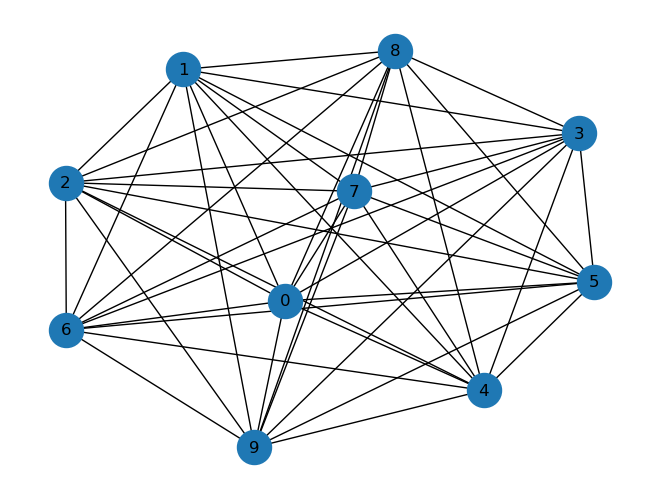

In [1]:
import numpy as np

import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
import sys 
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import Estimator as Estimator
# from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from scipy.optimize import minimize
from qiskit_algorithms.optimizers import SPSA

sys.path.append("../")
from testing_scripts.graphs_utils import generate_random_complete_graph,generate_k_regular_graph,compute_optimal_max_cut,build_max_cut_paulis

n = 10

# graph = rx.PyGraph()
# graph.add_nodes_from(np.arange(0, n, 1))
# edge_list = [(0, 1, 1.0), (0, 2, 1.0), (0, 4, 1.0), (1, 2, 1.0), (2, 3, 1.0), (3, 4, 1.0)]
# graph.add_edges_from(edge_list)
# draw_graph(graph, node_size=600, with_labels=True)


G=generate_random_complete_graph(num_vertices=n, weighted=False, seed=True)
graph = G
draw_graph(graph, node_size=600, with_labels=True)

In [2]:
from qiskit.quantum_info import SparsePauliOp
def build_max_cut_paulis(graph: rx.PyGraph) -> list[tuple[str, float]]:
    """Convert the graph to Pauli list.

    This function does the inverse of `build_max_cut_graph`
    """
    pauli_list = []
    for edge in list(graph.edge_list()):
        paulis = ["I"] * len(graph)
        paulis[edge[0]], paulis[edge[1]] = "Z", "Z"

        weight = graph.get_edge_data(edge[0], edge[1])

        pauli_list.append(("".join(paulis)[::-1], weight))

    return pauli_list


max_cut_paulis = build_max_cut_paulis(graph)

cost_hamiltonian = SparsePauliOp.from_list(max_cut_paulis)
print("Cost Function Hamiltonian:", cost_hamiltonian)

Cost Function Hamiltonian: SparsePauliOp(['IIIIIIIIZZ', 'IIIIIIIZIZ', 'IIIIIIZIIZ', 'IIIIIZIIIZ', 'IIIIZIIIIZ', 'IIIZIIIIIZ', 'IIZIIIIIIZ', 'IZIIIIIIIZ', 'ZIIIIIIIIZ', 'IIIIIIIZZI', 'IIIIIIZIZI', 'IIIIIZIIZI', 'IIIIZIIIZI', 'IIIZIIIIZI', 'IIZIIIIIZI', 'IZIIIIIIZI', 'ZIIIIIIIZI', 'IIIIIIZZII', 'IIIIIZIZII', 'IIIIZIIZII', 'IIIZIIIZII', 'IIZIIIIZII', 'IZIIIIIZII', 'ZIIIIIIZII', 'IIIIIZZIII', 'IIIIZIZIII', 'IIIZIIZIII', 'IIZIIIZIII', 'IZIIIIZIII', 'ZIIIIIZIII', 'IIIIZZIIII', 'IIIZIZIIII', 'IIZIIZIIII', 'IZIIIZIIII', 'ZIIIIZIIII', 'IIIZZIIIII', 'IIZIZIIIII', 'IZIIZIIIII', 'ZIIIZIIIII', 'IIZZIIIIII', 'IZIZIIIIII', 'ZIIZIIIIII', 'IZZIIIIIII', 'ZIZIIIIIII', 'ZZIIIIIIII'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
 1.+0.j, 1.+0.

/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/qiskit/visualization/circuit/matplotlib.py:1080: DeprecationWarning: The property ``qiskit.circuit.instruction.Instruction.condition`` is deprecated as of qiskit 1.3.0. It will be removed in 2.0.0.
  if getattr(op, "condition", None) or isinstance(op, SwitchCaseOp):


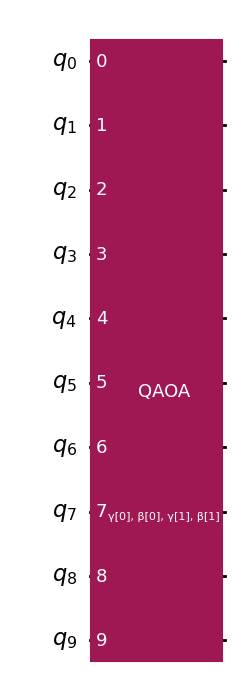

In [3]:
from qiskit.circuit.library import QAOAAnsatz

reps = 2
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=reps)
# circuit.measure_all()

circuit.draw('mpl')

In [4]:
circuit.parameters

ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(β[1]), ParameterVectorElement(γ[0]), ParameterVectorElement(γ[1])])

In [5]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeManilaV2


# QiskitRuntimeService.save_account(channel="ibm_quantum", token="<MY_IBM_QUANTUM_TOKEN>", overwrite=True, set_as_default=True)
# service = QiskitRuntimeService(channel='ibm_quantum')
# backend = service.least_busy(min_num_qubits=127)

# backend = FakeManilaV2()
backend = AerSimulator(method='statevector',device="GPU")


# # Create pass manager for transpilation
# pm = generate_preset_pass_manager(optimization_level=3,
#                                     backend=backend)

# candidate_circuit = pm.run(circuit)
# candidate_circuit.draw('mpl', fold=False, idle_wires=False)

candidate_circuit = circuit

In [6]:
initial_gamma = np.pi
initial_beta = np.pi/2
init_params = [initial_gamma, initial_beta] * reps

In [7]:
objective_func_vals = [] 

estimator = Estimator()

# estimator = Estimator(backend_options = {
#     'device': 'GPU'  # Set the device to GPU
# })

def cost_func_estimator(params, ansatz=candidate_circuit, hamiltonian=cost_hamiltonian, estimator=estimator):
    # global objective_func_vals

    # transform the observable defined on virtual qubits to
    # an observable defined on all physical qubits
    # isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)

    # pub = (ansatz, isa_hamiltonian, params)
    concrete_ansatz = ansatz.assign_parameters(params)

    job = estimator.run(concrete_ansatz,hamiltonian)

    # results = job.result()[0]
    # cost = results.data.evs
    cost = job.result().values[0]

    objective_func_vals.append(cost)


    return cost

/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/qiskit_aer/primitives/estimator.py:104: DeprecationWarning: The class ``qiskit.primitives.base.base_estimator.BaseEstimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. The `BaseEstimator` class is a type alias for the `BaseEstimatorV1` interface that has been deprecated in favor of explicitly versioned interface classes. It is recommended to migrate all implementations to use `BaseEstimatorV2`. However, for implementations incompatible with `BaseEstimatorV2`, `BaseEstimator` can be replaced with the explicitly versioned `BaseEstimatorV1` class.
  super().__init__(options=run_options)


In [8]:
cost_func_estimator(init_params)

/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/qiskit/primitives/base/validation.py:175: DeprecationWarning: The function ``qiskit.primitives.utils.init_observable()`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. Use the constructor of ``SparsePauliOp`` instead.
  return tuple(init_observable(obs) for obs in observables)
/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/qiskit_aer/primitives/estimator.py:202: DeprecationWarning: The function ``qiskit.primitives.utils.init_observable()`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. Use the constructor of ``SparsePauliOp`` instead.
  observable = init_observable(observable)
/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/qiskit/transpiler/passmanager.py:70: DeprecationWarning: The property ``qiskit.dagcircuit.dagcircuit.DAGCircuit.duration`` is 

np.float64(-0.416015625)

In [9]:

objective_func_vals = [] # Global variable
# with Session(backend=backend) as session:
#     # If using qiskit-ibm-runtime<0.24.0, change `mode=` to `session=`
#     estimator = Estimator(mode=session)
#     estimator.options.default_shots = 1000

#     # Set simple error suppression/mitigation options
#     estimator.options.dynamical_decoupling.enable = True
#     estimator.options.dynamical_decoupling.sequence_type = "XY4"
#     estimator.options.twirling.enable_gates = True
#     estimator.options.twirling.num_randomizations = "auto"

#     result = minimize(
#         cost_func_estimator,
#         init_params,
#         args=(candidate_circuit, cost_hamiltonian, estimator),
#         method="COBYLA",
#         tol=1e-2,
#     )
#     print(result)

result = minimize(
    cost_func_estimator,
    init_params,
    args=(candidate_circuit, cost_hamiltonian, estimator),
    method="COBYLA",
    tol=1e-12,
)

# from scipy.optimize import rosen, differential_evolution
# bounds = bounds=np.array([[0,2*np.pi]]*len(init_params), dtype=float)
# result = differential_evolution(cost_func_estimator, 
#                                 strategy='best1bin',
#                                 bounds=bounds,
#                                 popsize=1,
#                                 maxiter=200,
#                                 disp = False,
#                                 init='halton',
#                                 polish=False,
#                                 tol=1e-5
                                )

IndentationError: unexpected indent (2247706966.py, line 41)

In [ ]:
result

             message: Maximum number of iterations has been exceeded.
             success: False
                 fun: -4.509765625
                   x: [ 6.043e+00  3.064e+00  8.831e-02  1.229e+00]
                 nit: 200
                nfev: 1005
          population: [[ 6.043e+00  3.064e+00  8.831e-02  1.229e+00]
                       [ 6.045e+00  3.064e+00  8.831e-02  1.229e+00]
                       ...
                       [ 6.043e+00  3.064e+00  8.863e-02  1.229e+00]
                       [ 6.046e+00  3.064e+00  8.831e-02  1.229e+00]]
 population_energies: [-4.510e+00 -4.477e+00 -4.482e+00 -4.490e+00
                       -4.479e+00]

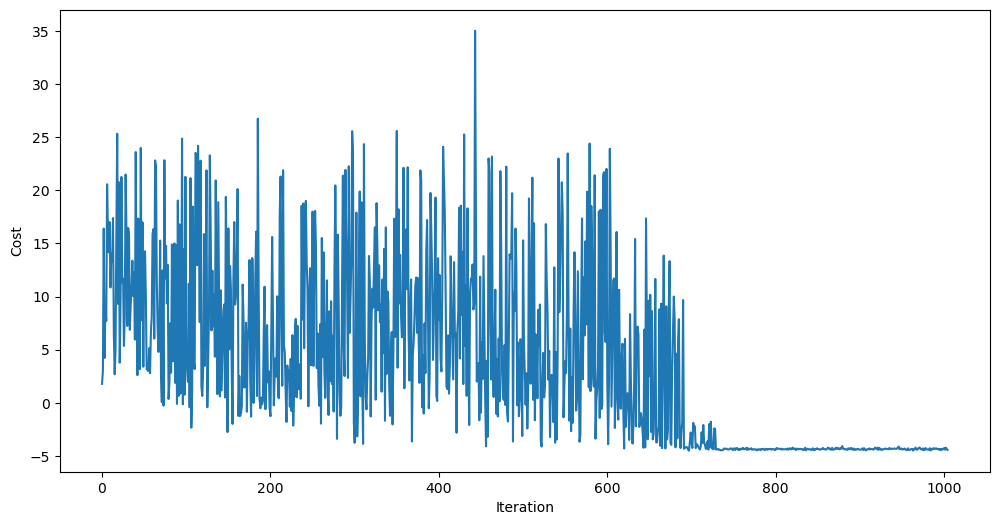

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/qiskit/visualization/circuit/matplotlib.py:1080: DeprecationWarning: The property ``qiskit.circuit.instruction.Instruction.condition`` is deprecated as of qiskit 1.3.0. It will be removed in 2.0.0.
  if getattr(op, "condition", None) or isinstance(op, SwitchCaseOp):


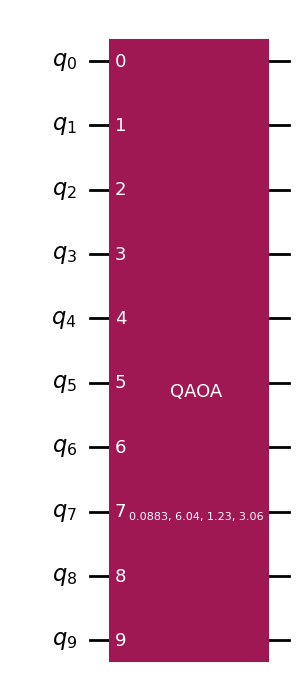

In [ ]:
optimized_circuit = candidate_circuit.assign_parameters(result.x)
optimized_circuit.draw('mpl', fold=False, idle_wires=False)

In [ ]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

# If using qiskit-ibm-runtime<0.24.0, change `mode=` to `backend=`
sampler = Sampler(mode=backend)
sampler.options.default_shots = 10000

# # Set simple error suppression/mitigation options
# sampler.options.dynamical_decoupling.enable = True
# sampler.options.dynamical_decoupling.sequence_type = "XY4"
# sampler.options.twirling.enable_gates = True
# sampler.options.twirling.num_randomizations = "auto"

pub= (optimized_circuit, )
job = sampler.run([pub], shots=int(1e4))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val/shots for key, val in counts_int.items()}
final_distribution_bin = {key: val/shots for key, val in counts_bin.items()}
print(final_distribution_int)

/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/qiskit_ibm_runtime/utils/validations.py:45: UserWarning: The 0-th circuit has no output classical registers so the result will be empty. Did you mean to add measurement instructions?
  warnings.warn(
/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/qiskit/primitives/backend_sampler_v2.py:173: UserWarning: The 0-th pub's circuit has no output classical registers and so the result will be empty. Did you mean to add measurement instructions?
  warnings.warn(
/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/qiskit_aer/backends/aer_compiler.py:695: DeprecationWarning: The property ``qiskit.circuit.instruction.Instruction.condition`` is deprecated as of qiskit 1.3.0. It will be removed in 2.0.0.
  or getattr(inst.operation, "condition", None)
/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/qiskit_aer/backends/aer_compiler.py:731: De

AerError: 'unknown instruction: QAOA'

In [ ]:
# auxiliary functions to sample most likely bitstring
def to_bitstring(integer, num_bits):
    result = np.binary_repr(integer, width=num_bits)
    return [int(digit) for digit in result]

keys = list(final_distribution_int.keys())
values = list(final_distribution_int.values())
most_likely = keys[np.argmax(np.abs(values))]
most_likely_bitstring = to_bitstring(most_likely, len(graph))
most_likely_bitstring.reverse()

print("Result bitstring:", most_likely_bitstring)

Result bitstring: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


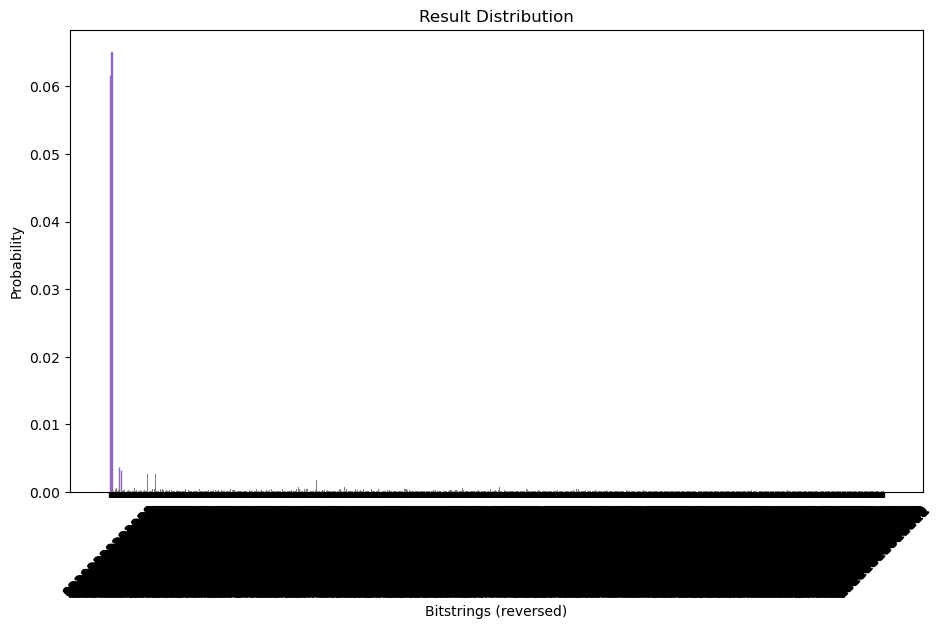

In [ ]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update({"font.size": 10})
final_bits = final_distribution_bin
values = np.abs(list(final_bits.values()))
top_4_values = sorted(values, reverse=True)[:4]
positions = []
for value in top_4_values:
    positions.append(np.where(values == value)[0][0])
fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(1, 1, 1)
plt.xticks(rotation=45)
plt.title("Result Distribution")
plt.xlabel("Bitstrings (reversed)")
plt.ylabel("Probability")
ax.bar(list(final_bits.keys()), list(final_bits.values()), color="tab:grey")
for p in positions:
    ax.get_children()[int(p)].set_color("tab:purple")
plt.show()

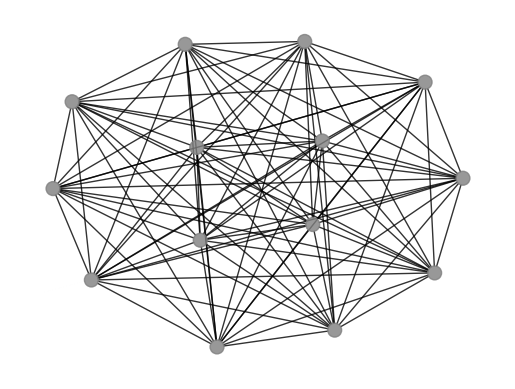

In [ ]:
# auxiliary function to plot graphs
def plot_result(G, x):
    colors = ["tab:grey" if i == 0 else "tab:purple" for i in x]
    pos, default_axes = rx.spring_layout(G), plt.axes(frameon=True)
    rx.visualization.mpl_draw(G, node_color=colors, node_size=100, alpha=0.8, pos=pos)

plot_result(graph, most_likely_bitstring)

In [ ]:
from typing import Sequence
def evaluate_sample(x: Sequence[int], graph: rx.PyGraph) -> float:
    assert len(x) == len(list(graph.nodes())), "The length of x must coincide with the number of nodes in the graph."
    return sum(x[u] * (1 - x[v]) + x[v] * (1 - x[u]) for u, v in list(graph.edge_list()))


cut_value= evaluate_sample(most_likely_bitstring, graph)
print('The value of the cut is:', cut_value)

The value of the cut is: 0
